<h1>3. Convolutional Neural Networks</h1>
In the previous section, we built and trained a simple model to classify ASL images. The model was able to learn how to correctly classify the training dataset with very high accuracy, but, it did not perform nearly as well on validation dataset. This behavior of not generalizing well to non-training data is called overfitting, and in this section, we will introduce a popular kind of model called a convolutional neural network that is especially good for reading images and classifying them.
<h2>3.1 Objectives</h2>
<ul>
<li>Prep data specifically for a CNN</li>
<li>Create a more sophisticated CNN model, understanding a greater variety of model layers</li>
<li>Train a CNN model and observe its performance</li>
</ul>

In [1]:
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

<h2>3.2 Loading and Preparing the Data</h2>
<h3>3.2.1 Preparing Images</h3>
Let's begin by loading our DataFrames like we did in the previous lab:

In [3]:
train_df = pd.read_csv("data/ASL/sign_mnist_train.csv")
valid_df = pd.read_csv("data/ASL/sign_mnist_valid.csv")

# Note - This ASL data is already flattened.

In [4]:
sample_df = train_df.head().copy()  # Grab the top 5 rows
sample_df.pop('label')
sample_x = sample_df.values
sample_x

array([[107, 118, 127, ..., 204, 203, 202],
       [155, 157, 156, ..., 103, 135, 149],
       [187, 188, 188, ..., 195, 194, 195],
       [211, 211, 212, ..., 222, 229, 163],
       [164, 167, 170, ..., 163, 164, 179]], dtype=int64)

In [5]:
sample_x.shape

(5, 784)

In this format, we don't have all the information about which pixels are near each other. Because of this, we can't apply convolutions that will detect features. Let's reshape our dataset so that they are in a 28x28 pixel format. This will allow our convolutions to associate groups of pixels and detect important features.

Note that for the first convolutional layer of our model, we need to have not only the height and width of the image, but also the number of color channels. Our images are grayscale, so we'll just have 1 channel.

That means that we need to convert the current shape (5, 784) to (5, 1, 28, 28). With NumPy arrays, we can pass a -1 for any dimension we wish to remain the same.

In [6]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHS = 1

sample_x = sample_x.reshape(-1, IMG_CHS, IMG_HEIGHT, IMG_WIDTH)
sample_x.shape

(5, 1, 28, 28)

<h3>3.2.2 Create a Dataset</h3>
Let's add the steps above into our MyDataset class.

In [7]:
class MyDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()  # Some operations below are in-place
        y_df = x_df.pop('label')
        x_df = x_df.values / 255  # Normalize values from 0 to 1
        x_df = x_df.reshape(-1, IMG_CHS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

<h3>3.2.3 Create a DataLoader</h3>
Next, let's create the DataLoader from the Dataset

In [8]:
BATCH_SIZE = 32

train_data = MyDataset(train_df)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
train_N = len(train_loader.dataset)

valid_data = MyDataset(valid_df)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
valid_N = len(valid_loader.dataset)

In [9]:
# Let's grab a batch from the DataLoader to make sure it works.
batch = next(iter(train_loader))
print(batch)
print(batch[0].shape)
print(batch[1].shape)

[tensor([[[[0.6000, 0.5961, 0.5961,  ..., 0.5098, 0.4980, 0.4941],
          [0.6157, 0.6118, 0.6118,  ..., 0.5216, 0.5137, 0.5020],
          [0.6275, 0.6275, 0.6314,  ..., 0.5373, 0.5294, 0.5176],
          ...,
          [0.8078, 0.8157, 0.8157,  ..., 0.1176, 0.0588, 0.0275],
          [0.4784, 0.4941, 0.5176,  ..., 0.1216, 0.0275, 0.0353],
          [0.3216, 0.3216, 0.3216,  ..., 0.1216, 0.0000, 0.0392]]],


        [[[0.1216, 0.2431, 0.2667,  ..., 0.6314, 0.6392, 0.6431],
          [0.1412, 0.2471, 0.2745,  ..., 0.6314, 0.6392, 0.6431],
          [0.1686, 0.2549, 0.2784,  ..., 0.6392, 0.6431, 0.6471],
          ...,
          [0.3098, 0.3255, 0.3451,  ..., 0.7490, 0.7529, 0.7608],
          [0.3137, 0.3294, 0.3451,  ..., 0.7490, 0.7529, 0.7608],
          [0.3098, 0.3294, 0.3490,  ..., 0.7569, 0.7608, 0.7647]]],


        [[[0.4745, 0.4902, 0.5059,  ..., 0.6549, 0.6588, 0.6549],
          [0.4784, 0.4941, 0.5137,  ..., 0.6588, 0.6627, 0.6627],
          [0.4784, 0.4980, 0.5137,  .

<h2>3.3 Creating a Convolutional Model</h2>
These days, many data scientists start their projects by borrowing model properties from a similar project. Assuming the problem is not totally unique, there's a great chance that people have created models that will perform well which are posted in online repositories like TensorFlow Hub (https://www.tensorflow.org/hub) and the NGC Catalog (https://catalog.ngc.nvidia.com/search?filters=resourceType|Model|model). Today, we'll provide a model that will work well for this problem.

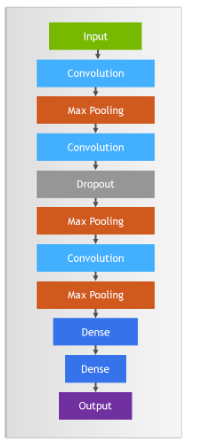

We covered many of the different kinds of layers in the lecture, and we will go over them all here with links to their documentation. When in doubt, read the official documentation (or ask Stack Overflow https://stackoverflow.com/questions).



In [10]:
n_classes = 24
kernel_size = 3
flattened_img_size = 75 * 3 * 3

model = nn.Sequential(
    # First convolution
    nn.Conv2d(IMG_CHS, 25, kernel_size, stride=1, padding=1),  # 25 x 28 x 28
    nn.BatchNorm2d(25),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14
    # Second convolution
    nn.Conv2d(25, 50, kernel_size, stride=1, padding=1),  # 50 x 14 x 14
    nn.BatchNorm2d(50),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7
    # Third convolution
    nn.Conv2d(50, 75, kernel_size, stride=1, padding=1),  # 75 x 7 x 7
    nn.BatchNorm2d(75),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3
    # Flatten to Dense
    nn.Flatten(),
    nn.Linear(flattened_img_size, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, n_classes)
)

<h3>3.3.1 Conv2D</h3>

https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

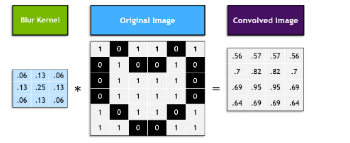

These are our 2D convolutional layers. Small kernels will go over the input image and detect features that are important for classification. Earlier convolutions in the model will detect simple features such as lines. Later convolutions will detect more complex features. Let's look at our first Conv2D layer:

nn.Conv2d(IMG_CHS, 25, kernel_size, stride=1, padding=1)

25 refers to the number of filters that will be learned. Even though kernel_size = 3, PyTorch will assume we want 3 x 3 filters. Stride refer to the step size that the filter will take as it passes over the image. Padding refers to whether the output image that's created from the filter will match the size of the input image.

<h3>3.3.2 BatchNormalization</h3>

https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html

Like normalizing our inputs, batch normalization scales the values in the hidden layers to improve training. Read more about it in detail here (https://blog.paperspace.com/busting-the-myths-about-batch-normalization/).

There is a debate on best where to put the batch normalization layer. This Stack Overflow post (https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) compiles many perspectives.

<h3>3.3.3 MaxPool2D</h3>

https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html

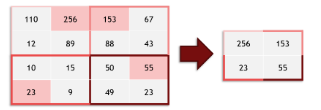

Max pooling takes an image and essentially shrinks it to a lower resolution. It does this to help the model be <u>robust to translation (objects moving side to side) </u>, and also <u>makes our model faster</u>.

<h3>3.3.4 Dropout</h3>

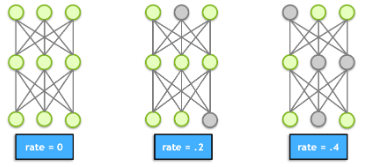

Dropout is a technique for preventing overfitting. Dropout randomly selects a subset of neurons and turns them off, so that they do not participate in forward or backward propagation in that particular pass. This helps to make sure that the network is robust and redundant, and does not rely on any one area to come up with answers.

<h3>3.3.5 Flatten</h3>

https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html

Flatten takes the output of one layer which is multidimensional, and flattens it into a one-dimensional array. The output is called a feature vector and will be connected to the final classification layer.

<h3>3.3.6 Linear</h3>

https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html

We have seen dense linear layers before in our earlier models. Our first dense layer (512 units) takes the feature vector as input and learns which features will contribute to a particular classification. The second dense layer (24 units) is the final classification layer that outputs our prediction.


<h2>3.4 Summarizing the Model</h2>
This may feel like a lot of information, but don't worry. It's not critical that to understand everything right now in order to effectively train convolutional models. Most importantly we know that they can help with extracting useful information from images, and can be used in classification tasks.

In [12]:
model = model.to(device) # chaneg to GPU if available
# model = torch.compile(model) # not available on windows
model

Sequential(
  (0): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.2, inplace=False)
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Flatten(start_dim=1, end_dim=-1)
  (14): Linear(in_features=675, out_features=512, bias=True)
  (15): Dropout(p=0.3, inplace=False)
  (16): ReLU()
  (17): Linear(in_features

In [13]:

# Since the problem we are trying to solve is still the same (classifying ASL images), we will continue to use the same loss_function and accuracy metric.

loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters())

def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N



<h2>3.5 Training the Model</h2>
Despite the very different model architecture, the training looks exactly the same.


In [14]:

def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

def train():
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

epochs = 20

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()

Epoch: 0
Train - Loss: 249.0680 Accuracy: 0.9144
Valid - Loss: 47.7811 Accuracy: 0.9182
Epoch: 1
Train - Loss: 16.6519 Accuracy: 0.9949
Valid - Loss: 37.8442 Accuracy: 0.9453
Epoch: 2
Train - Loss: 12.9539 Accuracy: 0.9961
Valid - Loss: 15.9272 Accuracy: 0.9711
Epoch: 3
Train - Loss: 15.0326 Accuracy: 0.9946
Valid - Loss: 15.8600 Accuracy: 0.9735
Epoch: 4
Train - Loss: 6.2119 Accuracy: 0.9981
Valid - Loss: 43.0381 Accuracy: 0.9541
Epoch: 5
Train - Loss: 5.9221 Accuracy: 0.9982
Valid - Loss: 10.8163 Accuracy: 0.9810
Epoch: 6
Train - Loss: 11.3623 Accuracy: 0.9965
Valid - Loss: 16.3022 Accuracy: 0.9727
Epoch: 7
Train - Loss: 4.6468 Accuracy: 0.9984
Valid - Loss: 38.5634 Accuracy: 0.9446
Epoch: 8
Train - Loss: 6.5042 Accuracy: 0.9979
Valid - Loss: 30.7232 Accuracy: 0.9644
Epoch: 9
Train - Loss: 6.3269 Accuracy: 0.9983
Valid - Loss: 12.9031 Accuracy: 0.9817
Epoch: 10
Train - Loss: 3.2515 Accuracy: 0.9989
Valid - Loss: 25.2425 Accuracy: 0.9682
Epoch: 11
Train - Loss: 5.4071 Accuracy: 0.9982

<h3>3.5.1 Discussion of Results</h3>
It looks like this model is significantly improved! The training accuracy is very high, and the validation accuracy has improved as well. This is a great result, as all we had to do was swap in a new model.

You may have noticed the validation accuracy jumping around. This is an indication that our model is still not generalizing perfectly. Fortunately, there's more that we can do. Let's talk about it in the next lecture.

<h2>3.6 Summary</h2>
In this section, we utilized several new kinds of layers to implement a CNN, which performed better than the more simple model used in the last section. Hopefully the overall process of creating and training a model with prepared data is starting to become even more familiar.

<h3>3.6.1 Clear the Memory</h3>
Before moving on, please execute the following cell to clear up the GPU memory. This is required to move on to the next notebook.


In [ ]:
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

: 